<a href="https://colab.research.google.com/github/Grashch/Kaggle_tasks/blob/main/SHAP_Values.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import shap
import matplotlib.pyplot as plt


# 1. Создаём данные (продолжение)
np.random.seed(42)
data = pd.DataFrame({
    'Дождь_мм': np.random.normal(60, 20, 100),
    'Температура_C': np.random.normal(22, 4, 100),
    'Удобрения_кг': np.random.uniform(0, 150, 100),
    'Кислотность_pH': np.random.uniform(5.5, 7.5, 100),
    'Площадь_га': np.random.uniform(1, 10, 100),
    'Сорт_семян': np.random.randint(1, 6, 100)
})

# Целевая переменная (урожайность) с нелинейными зависимостями
data['Урожайность_т'] = (
    0.4 * data['Дождь_мм'] +
    -0.2 * (data['Температура_C'] - 22)**2 +  # оптимум при 22 °C
    1.2 * data['Удобрения_кг'] +
    -1.0 * (data['Кислотность_pH'] - 6.5)**2 +  # оптимум при pH 6.5
    0.1 * data['Площадь_га'] +
    2.0 * data['Сорт_семян'] +
    np.random.normal(0, 3, 100)  # шум
)

# Разделяем признаки и цель
X = data.drop('Урожайность_т', axis=1)
y = data['Урожайность_т']

In [2]:
# 2. Обучаем модель
model = RandomForestRegressor(n_estimators=50, random_state=42)
model.fit(X, y)

RandomForestRegressor(n_estimators=50, random_state=42)

In [3]:
# 3. Создаём SHAP‑эксплайнер
explaner = shap.TreeExplainer(model)
shap_values = explaner.shap_values(X)

In [4]:
# Базовый уровень (средний прогноз)
expected_value = explaner.expected_value.item()
expected_value

114.91751714313318

# **Применение основных методов SHAP**

1. **summary_plot** — общая важность признаков

/tmp/ipython-input-321775720.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X, plot_type='bar', show=False) # 'show=False' предотвращает автоматический показ


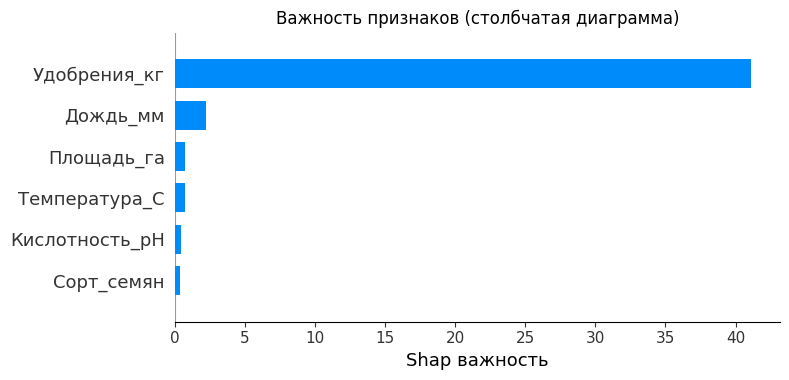

In [5]:
plt.figure()
shap.summary_plot(shap_values, X, plot_type='bar', show=False) # 'show=False' предотвращает автоматический показ
plt.title('Важность признаков (столбчатая диаграмма)')
plt.xlabel('Shap важность')
plt.tight_layout() # Автоматически подгоняет расположение элементов, чтобы заголовок не обрезался
plt.show()

/tmp/ipython-input-1690304101.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X, show=False)


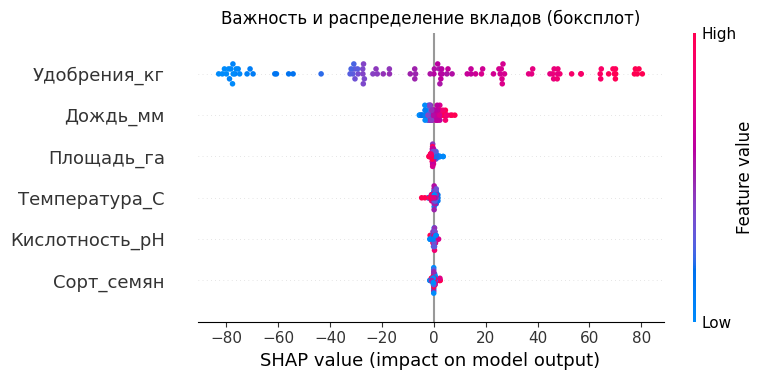

In [6]:
plt.figure()
shap.summary_plot(shap_values, X, show=False)
plt.title("Важность и распределение вкладов (боксплот)")
plt.tight_layout() # Автоматически подгоняет расположение элементов, чтобы заголовок не обрезался
plt.show()

Что увидим:
*   Столбчатая диаграмма: самые высокие столбцы — самые важные признаки. Например, «Удобрения_кг» и «Сорт_семян» могут быть вверху.
*   Боксплот:


    *   Широкие «усы» → признак сильно варьируется по влиянию.
    *   Смещение точек влево/вправо → преобладает отрицательное/положительное   влияние.
    *   Цвет точек (по значению признака) → например, высокие значения «Кислотности_pH» чаще дают отрицательный вклад.

2. **dependence_plot** — анализ взаимодействия признаков

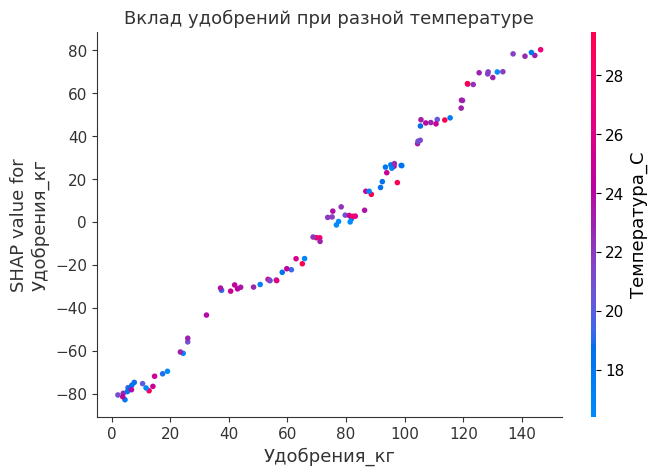

In [7]:
# Как «Удобрения_кг» влияют на прогноз при разной температуре
shap.dependence_plot(
    "Удобрения_кг",
    shap_values,
    X,
    interaction_index="Температура_C",
    title="Вклад удобрений при разной температуре"
)
plt.show()

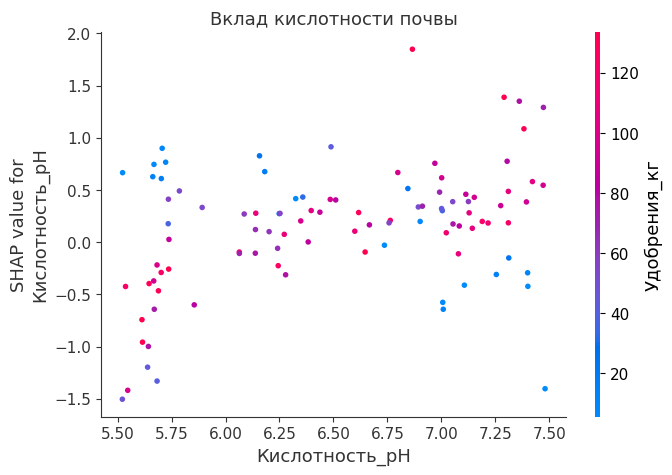

In [10]:
# Как «Кислотность_pH» влияет на прогноз
shap.dependence_plot(
    "Кислотность_pH",
    shap_values,
    X,
    title="Вклад кислотности почвы"
)
plt.show()

Как читать:
*   По горизонтали: значение анализируемого признака (например, кг удобрений).
*   По вертикали: SHAP‑значение (вклад в урожайность).
*   Цвет точек: значение второго признака (например, температура).

Пример выводов:
*   Если для высокой температуры (красные точки) линия идёт круче → удобрения эффективнее в тёплую погоду.
*   Если график «Кислотности_pH» имеет U‑образную форму → есть оптимальный уровень pH (около 6.5), где вклад максимален.